# Mapping and Classification of Paddy Fields and Settlements Using Sentinel-2A Imagery
**Study area: Hyderabad (Sindh)** — Random Forest, 70 % training / 30 % testing split **per polygon**.

Run the cells top to bottom (VS Code: *Run Cell*, or open `code-klasifikasiLahan.ipynb`).
Put `hyd_rice_building_data.geojson` in the project folder (or in `data/geojson/`).

| Step | Output |
|---|---|
| 1 Clean GeoJSON & split | `data/geojson/input2.geojson`, `data/csv/...split...csv` |
| 2 Sentinel-2A via openEO | `data/tif/sentinel2_area_studi.tif` |
| 3 Spectral features per polygon / pixel | `data/csv/split_dataset/fitur_piksel_*.csv`, `data/csv/fitur_sampel.csv` |
| 4 Random Forest + validation | metrics, confusion matrix |
| 5 Predict whole area | `data/tif/klasifikasi_sawah_pemukiman.tif`, `assets/peta_klasifikasi.png` |
| 6 3D map on DEM | `data/tif/dem_area_studi.tif`, `assets/peta_3d.html` |

## 0. Setup
`pip install openeo geopandas rasterio scikit-learn pandas numpy matplotlib scipy plotly`

In [1]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling
from shapely.geometry import shape, box
from scipy import ndimage
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, cohen_kappa_score,
                             classification_report)

# Work relative to this file / notebook folder, regardless of where VS Code was launched from
try:
    BASE = Path(__file__).resolve().parent
except NameError:                      # running as a notebook
    BASE = Path.cwd()
os.chdir(BASE)

# ---- Configuration -------------------------------------------------------------------------
RAW_CANDIDATES = [BASE / "data/geojson/hyd_rice_building_data.geojson",
                  BASE / "hyd_rice_building_data.geojson"]
GEOJSON_CLEAN = BASE / "data/geojson/input2.geojson"
TIF = BASE / "data/tif/sentinel2_area_studi.tif"
DEM_TIF = BASE / "data/tif/dem_area_studi.tif"
OUT_TIF = BASE / "data/tif/klasifikasi_sawah_pemukiman.tif"
SPLIT_DIR = BASE / "data/csv/split_dataset"
DATE_RANGE = ["2025-08-24", "2026-08-23"]
MAX_CLOUD = 30
ALL_TOUCHED = True        # small polygons: keep every pixel the polygon touches (as in the original report)
TEST_SIZE, SEED = 0.30, 42
VERTICAL_EXAGGERATION = 8  # 3D map only; terrain around Hyderabad is almost flat

# Some polygons in the raw file have no attribute. Fill in their class by raw-file index if you know it,
# e.g. {4: "Sawah"}. Unlisted unlabeled polygons are ignored.
UNLABELED_AS = {}

for d in ("data/geojson", "data/tif", "data/csv", SPLIT_DIR, "assets"):
    Path(d).mkdir(parents=True, exist_ok=True)

## 1. Input data: clean the GeoJSON and split train / test per polygon
The raw file has no `Type` column and inconsistent keys (`Sawah`, `sawah `, ``sawah` ``, `building`, `buidling`).
Here they are normalised to `Sawah` / `Pemukiman`; empty or degenerate polygons are dropped.
Splitting by **polygon** (not pixel) prevents leakage from spatially autocorrelated neighbouring pixels.

In [3]:
raw_path = next((p for p in RAW_CANDIDATES if p.exists()), None)
if raw_path is None:
    raise FileNotFoundError("hyd_rice_building_data.geojson not found. Put it next to this file or in data/geojson/")

CLASS_MAP = {"sawah": "Sawah", "building": "Pemukiman", "buidling": "Pemukiman"}   # 'buidling' = typo in source
raw = json.load(open(raw_path))

records, geoms, dropped = [], [], []
for i, f in enumerate(raw["features"]):
    props = f.get("properties") or {}
    key = next(iter(props), None)
    
    # Safe coordinate ring check before converting to Shapely geometry
    geom_type = f.get("geometry", {}).get("type", "").lower()
    coords = f.get("geometry", {}).get("coordinates", [])
    
    if geom_type == "polygon":
        if not coords or len(coords[0]) < 4:
            dropped.append((i, "degenerate polygon ring (fewer than 4 coordinates)"))
            continue
        ring = coords[0]
    elif geom_type == "multipolygon":
        if not coords or len(coords[0][0]) < 4:
            dropped.append((i, "degenerate multipolygon ring"))
            continue
        ring = coords[0][0]
    else:
        dropped.append((i, f"unsupported geometry type: {geom_type}"))
        continue

    label = CLASS_MAP.get(key.strip().strip("`").lower()) if key else UNLABELED_AS.get(i)
    try:
        geom = shape(f["geometry"])
    except Exception as e:
        dropped.append((i, f"failed to parse geometry: {str(e)}"))
        continue

    if len(set(map(tuple, ring))) < 3 or geom.area == 0:
        dropped.append((i, "degenerate geometry"))
    elif label is None:
        dropped.append((i, "valid polygon but no label"))
    else:
        records.append({"Type": label, "src_id": props.get(key), "src_index": i})
        geoms.append(geom)

samples = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")
samples["ID_Poligon"] = samples.groupby("Type").cumcount().add(1).map("{:02d}".format)
samples["ID_Poligon"] = samples["Type"] + "_" + samples["ID_Poligon"]
if not samples.geometry.is_valid.all():
    samples["geometry"] = samples.geometry.buffer(0)

print("Kept:", samples["Type"].value_counts().to_dict(), "| dropped:", dropped)

# Study-area polygon (the raw file has none): sample bounding box + ~300 m margin
minx, miny, maxx, maxy = samples.total_bounds
M = 0.003
area_geom = box(minx - M, miny - M, maxx + M, maxy + M)
area_gdf = gpd.GeoDataFrame({"Type": ["Area"], "ID_Poligon": ["Area_01"]}, geometry=[area_geom], crs="EPSG:4326")
pd.concat([samples[["Type", "ID_Poligon", "geometry"]], area_gdf], ignore_index=True).to_file(
    GEOJSON_CLEAN, driver="GeoJSON")

# Stratified train/test split per polygon
train_ids, test_ids = train_test_split(samples["ID_Poligon"], test_size=TEST_SIZE,
                                       stratify=samples["Type"], random_state=SEED)
samples["Status_Split"] = np.where(samples["ID_Poligon"].isin(train_ids), "Training", "Testing")

samples[["ID_Poligon", "Type", "Status_Split"]].to_csv(BASE / "data/csv/pembagian_dataset_train_test.csv", index=False)
for s, name in (("Training", "data_training_poligon.csv"), ("Testing", "data_testing_poligon.csv")):
    samples.loc[samples.Status_Split == s, ["ID_Poligon", "Type"]].to_csv(SPLIT_DIR / name, index=False)

print(pd.crosstab(samples["Type"], samples["Status_Split"], margins=True))

Kept: {'Pemukiman': 52, 'Sawah': 47} | dropped: [(0, 'degenerate polygon ring (fewer than 4 coordinates)'), (3, 'valid polygon but no label'), (4, 'valid polygon but no label'), (8, 'degenerate polygon ring (fewer than 4 coordinates)'), (13, 'valid polygon but no label'), (14, 'degenerate geometry')]
Status_Split  Testing  Training  All
Type                                
Pemukiman          16        36   52
Sawah              14        33   47
All                30        69   99


## 2. Sentinel-2A image acquisition via openEO
Level-2A surface reflectance (`SENTINEL2_L2A`) from the Copernicus Data Space Ecosystem, one-year **median** composite,
pixel-level cloud masking with the SCL band (classes 3, 8, 9, 10, 11). The download is skipped if the `.tif` already exists.
The first run opens a browser for the Copernicus login.

In [4]:
if TIF.exists():
    print("Using existing", TIF)
else:
    import openeo
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    bands = ["B02", "B03", "B04", "B08", "B11", "SCL"]
    cube = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent={"west": area_geom.bounds[0], "south": area_geom.bounds[1],
                        "east": area_geom.bounds[2], "north": area_geom.bounds[3], "crs": "EPSG:4326"},
        temporal_extent=DATE_RANGE, bands=bands, max_cloud_cover=MAX_CLOUD)
    scl = cube.band("SCL")
    bad = (scl == 3) | (scl == 8) | (scl == 9) | (scl == 10) | (scl == 11)
    cube = cube.mask(bad.resample_cube_spatial(cube)).filter_bands(bands[:-1])
    cube = cube.reduce_dimension(dimension="t", reducer="median")
    cube.download(str(TIF), format="GTiff")
    print("Saved", TIF)

with rasterio.open(TIF) as src:
    print(f"{src.count} bands | {src.width} x {src.height} px | CRS {src.crs} | pixel {src.res}")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=PHCB-YIUI 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Saved c:\Users\Usser\Downloads\PSD_Rice_Building_Tugas4\Hyd_Rice_Building_Tugas4\data\tif\sentinel2_area_studi.tif
5 bands | 157 x 381 px | CRS EPSG:32642 | pixel (10.0, 10.0)


## 3. Spectral features and derived indices
8 features per pixel: B02, B03, B04, B08, B11 + NDVI, NDWI, NDBI (digital numbers / 10 000 = reflectance).

NDVI = (B08 − B04) / (B08 + B04)  NDWI = (B03 − B08) / (B03 + B08)  NDBI = (B11 − B08) / (B11 + B08)

In [5]:
FEATS = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI", "NDBI"]


def nd(a, b):
    """Normalised difference (a-b)/(a+b), safe against division by zero."""
    s = a + b
    return np.divide(a - b, s, out=np.full_like(s, np.nan), where=np.abs(s) > 1e-9)


def add_indices(bands5):
    """bands5: (5, ...) reflectance in order B02,B03,B04,B08,B11  ->  (8, ...)"""
    b02, b03, b04, b08, b11 = bands5
    return np.concatenate([bands5, nd(b08, b04)[None], nd(b03, b08)[None], nd(b11, b08)[None]], axis=0)


def valid_pixels(bands5):
    """True where all 5 bands are finite, positive and physically plausible reflectance."""
    return np.isfinite(bands5).all(axis=0) & (bands5 > 0).all(axis=0) & (bands5 < 1.5).all(axis=0)


rows = []
with rasterio.open(TIF) as src:
    smp = samples.to_crs(src.crs)
    for _, r in smp.iterrows():
        try:
            m, _ = rio_mask(src, [r.geometry], crop=True, all_touched=ALL_TOUCHED, filled=False)
        except ValueError:            # polygon outside the raster
            continue
        arr = np.ma.filled(m.astype("float32"), np.nan)[:5] / 10000
        feats = add_indices(arr)
        keep = valid_pixels(arr) & np.isfinite(feats).all(axis=0)
        for px in feats[:, keep].T:
            rows.append([r.ID_Poligon, r.Type, r.Status_Split, *px])

pix = pd.DataFrame(rows, columns=["ID_Poligon", "Type", "Status_Split", *FEATS])
pix[pix.Status_Split == "Training"].to_csv(SPLIT_DIR / "fitur_piksel_training.csv", index=False)
pix[pix.Status_Split == "Testing"].to_csv(SPLIT_DIR / "fitur_piksel_testing.csv", index=False)

per_poly = pix.groupby(["ID_Poligon", "Type", "Status_Split"])[FEATS].mean().reset_index()
per_poly.to_csv(BASE / "data/csv/fitur_sampel.csv", index=False)

summary = (pix.groupby(["Type", "Status_Split"])
           .agg(Polygons=("ID_Poligon", "nunique"), Pixels=("B02", "size"),
                NDVI=("NDVI", "mean"), NDWI=("NDWI", "mean"), NDBI=("NDBI", "mean")).round(4))
print(f"Total pixels: {len(pix)}")
print(summary.to_string())

Total pixels: 3668
                        Polygons  Pixels    NDVI    NDWI    NDBI
Type      Status_Split                                          
Pemukiman Testing             16     290  0.0764 -0.1268  0.0546
          Training            36     626  0.0874 -0.1385  0.0571
Sawah     Testing             14     821  0.4900 -0.5160 -0.1188
          Training            33    1931  0.4805 -0.5033 -0.1168


## 4. Random Forest classification and validation
Trained **only** on pixels from training polygons, evaluated **only** on pixels from unseen testing polygons.

Training pixels: 2557 | Testing pixels: 1111
Training accuracy: 1.0000
Testing accuracy : 0.9838
Cohen's Kappa    : 0.9584

Confusion matrix (testing):
                  Pred Sawah  Pred Pemukiman
Actual Sawah             808              13
Actual Pemukiman           5             285 

              precision    recall  f1-score   support

       Sawah      0.994     0.984     0.989       821
   Pemukiman      0.956     0.983     0.969       290

    accuracy                          0.984      1111
   macro avg      0.975     0.983     0.979      1111
weighted avg      0.984     0.984     0.984      1111

Feature importance:
 NDVI    0.260
NDWI    0.211
B02     0.176
B03     0.141
B04     0.090
NDBI    0.070
B11     0.036
B08     0.015


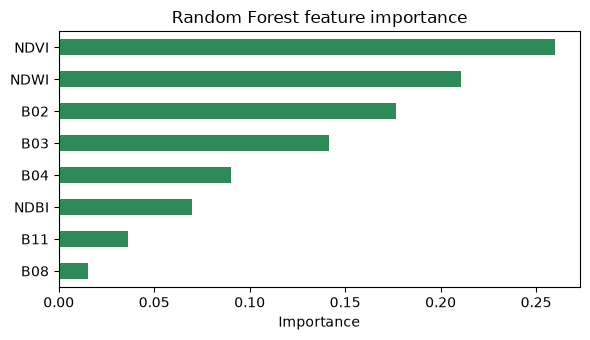

In [6]:
tr, te = pix[pix.Status_Split == "Training"], pix[pix.Status_Split == "Testing"]
LABELS = ["Sawah", "Pemukiman"]

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)
rf.fit(tr[FEATS], tr["Type"])
pred_tr, pred_te = rf.predict(tr[FEATS]), rf.predict(te[FEATS])

print(f"Training pixels: {len(tr)} | Testing pixels: {len(te)}")
print(f"Training accuracy: {accuracy_score(tr.Type, pred_tr):.4f}")
print(f"Testing accuracy : {accuracy_score(te.Type, pred_te):.4f}")
print(f"Cohen's Kappa    : {cohen_kappa_score(te.Type, pred_te):.4f}\n")

cm = pd.DataFrame(confusion_matrix(te.Type, pred_te, labels=LABELS),
                  index=[f"Actual {l}" for l in LABELS], columns=[f"Pred {l}" for l in LABELS])
print("Confusion matrix (testing):")
print(cm, "\n")
print(classification_report(te.Type, pred_te, labels=LABELS, digits=3, zero_division=0))

imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values(ascending=False)
print("Feature importance:\n", imp.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 3.5))
imp[::-1].plot.barh(ax=ax, color="#2e8b57")
ax.set_xlabel("Importance"); ax.set_title("Random Forest feature importance")
plt.tight_layout(); plt.show()

## 5. Predict the whole area and draw the 2D map
Output GeoTIFF: `0` = no data, `1` = rice field (Sawah), `2` = settlement (Pemukiman).

In [7]:
with rasterio.open(TIF) as src:
    img = src.read()[:5].astype("float32") / 10000
    prof = src.profile.copy()
    bounds, raster_crs = src.bounds, src.crs

ok = valid_pixels(img)
Xall = add_indices(img).reshape(8, -1).T
ok_flat = ok.ravel() & np.isfinite(Xall).all(axis=1)

cls = np.zeros(Xall.shape[0], dtype="uint8")
cls[ok_flat] = np.where(rf.predict(pd.DataFrame(Xall[ok_flat], columns=FEATS)) == "Sawah", 1, 2)
cls = cls.reshape(img.shape[1:])

prof.update(count=1, dtype="uint8", nodata=0, compress="lzw")
with rasterio.open(OUT_TIF, "w", **prof) as dst:
    dst.write(cls, 1)

share = {k: round((cls == v).sum() / max((cls > 0).sum(), 1) * 100, 1) for k, v in (("Sawah", 1), ("Pemukiman", 2))}
print("Area share of classified pixels (%):", share)

Area share of classified pixels (%): {'Sawah': np.float64(34.7), 'Pemukiman': np.float64(65.3)}


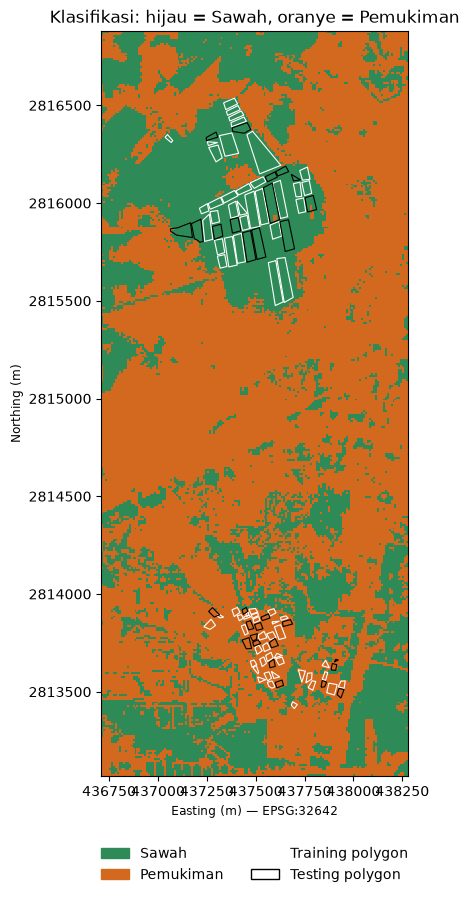

In [8]:
COLORS = {1: "#2e8b57", 2: "#d2691e"}
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

fig, ax = plt.subplots(figsize=(6, 9))
ax.imshow(np.ma.masked_equal(cls, 0), cmap=ListedColormap([COLORS[1], COLORS[2]]), vmin=1, vmax=2,
          extent=extent, interpolation="nearest")
smp_plot = samples.to_crs(raster_crs)
smp_plot[smp_plot.Status_Split == "Training"].boundary.plot(ax=ax, color="white", linewidth=0.8)
smp_plot[smp_plot.Status_Split == "Testing"].boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.legend(handles=[Patch(color=COLORS[1], label="Sawah"), Patch(color=COLORS[2], label="Pemukiman"),
                   Patch(fill=False, ec="white", label="Training polygon"),
                   Patch(fill=False, ec="black", label="Testing polygon")],
          loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
ax.set_title("Klasifikasi: hijau = Sawah, oranye = Pemukiman")
ax.set_xlabel(f"Easting (m) — {raster_crs}"); ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", useOffset=False)
plt.tight_layout()
plt.savefig(BASE / "assets/peta_klasifikasi.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Interactive 3D map on Copernicus DEM (30 m)
The DEM is downloaded with openEO (skipped if present), resampled onto the 10 m classification grid, and the
classification is draped over the surface. Hyderabad is very flat, so the vertical scale is exaggerated
(`VERTICAL_EXAGGERATION`, clamped so the relief stays visible but not absurd); the real factor is printed in the figure subtitle.

In [9]:
if DEM_TIF.exists():
    print("Using existing", DEM_TIF)
else:
    import openeo
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    w, s, e, n = area_geom.buffer(0.002).bounds
    dem_cube = conn.load_collection("COPERNICUS_30", spatial_extent={"west": w, "south": s, "east": e, "north": n},
                                    bands=["DEM"]).max_time()
    dem_cube.download(str(DEM_TIF), format="GTiff")
    print("Saved", DEM_TIF)

Authenticated using refresh token.
Saved c:\Users\Usser\Downloads\PSD_Rice_Building_Tugas4\Hyd_Rice_Building_Tugas4\data\tif\dem_area_studi.tif


In [10]:
def dem_on_grid(dem_path, ref_profile):
    """Resample the DEM (any CRS / resolution) onto the classification grid; fill holes by nearest neighbour."""
    out = np.full((ref_profile["height"], ref_profile["width"]), np.nan, dtype="float32")
    with rasterio.open(dem_path) as d:
        reproject(source=rasterio.band(d, 1), destination=out,
                  src_transform=d.transform, src_crs=d.crs, src_nodata=d.nodata,
                  dst_transform=ref_profile["transform"], dst_crs=ref_profile["crs"],
                  dst_nodata=np.nan, init_dest_nodata=True, resampling=Resampling.bilinear)
    out[~np.isfinite(out) | (out < -100)] = np.nan
    if np.isnan(out).all():
        raise ValueError("DEM does not overlap the study area.")
    if np.isnan(out).any():
        idx = ndimage.distance_transform_edt(np.isnan(out), return_distances=False, return_indices=True)
        out = out[tuple(idx)]
    return out


def prepare_3d(dem, classes, res_x, res_y, max_cells=450):
    """Downsample, flip so row 0 = south (y increases northwards) and return plotting arrays."""
    step = max(1, int(np.ceil(max(dem.shape) / max_cells)))
    z = np.flipud(dem[::step, ::step])
    c = np.flipud(classes[::step, ::step]).astype("float32")
    c[c == 0] = np.nan                      # no data -> not coloured
    x = np.arange(z.shape[1]) * res_x * step
    y = np.arange(z.shape[0]) * res_y * step
    return x, y, z, c


dem = dem_on_grid(DEM_TIF, prof)
res_x, res_y = abs(prof["transform"].a), abs(prof["transform"].e)
x, y, z, c = prepare_3d(dem, cls, res_x, res_y)
print(f"Elevation {np.nanmin(z):.1f} – {np.nanmax(z):.1f} m (range {np.nanmax(z) - np.nanmin(z):.1f} m) | grid {z.shape[1]} x {z.shape[0]}")

Elevation 16.1 – 28.8 m (range 12.7 m) | grid 157 x 381


In [11]:
import plotly.graph_objects as go

span_x, span_y = x.max(), y.max()
span_z = max(float(np.nanmax(z) - np.nanmin(z)), 1.0)
big = max(span_x, span_y)
ar = dict(x=span_x / big, y=span_y / big,
          z=float(np.clip(span_z * VERTICAL_EXAGGERATION / big, 0.05, 0.4)))   # keep the relief visible but not absurd
real_ve = ar["z"] * big / span_z

fig3d = go.Figure(go.Surface(
    x=x, y=y, z=z, surfacecolor=c, cmin=1, cmax=2,
    colorscale=[[0, COLORS[1]], [0.5, COLORS[1]], [0.5, COLORS[2]], [1, COLORS[2]]],
    colorbar=dict(title="Kelas", tickvals=[1.25, 1.75], ticktext=["Sawah", "Pemukiman"],
                  len=0.45, thickness=16, x=0.94),
    lighting=dict(ambient=0.65, diffuse=0.85, roughness=0.9, specular=0.05, fresnel=0.1),
    hovertemplate="Timur %{x:.0f} m<br>Utara %{y:.0f} m<br>Elevasi %{z:.1f} m<extra></extra>"))
fig3d.update_layout(
    title=dict(text=f"Klasifikasi Sawah & Pemukiman (3D Surface Relief)<br>"
                    f"<sup>Copernicus DEM 30 m · vertical exaggeration ×{real_ve:.0f}</sup>", x=0.02),
    scene=dict(xaxis=dict(title="Timur (m)"), yaxis=dict(title="Utara (m)"),
               zaxis=dict(title="Elevasi (m)", range=[float(np.nanmin(z)) - 0.5, float(np.nanmax(z)) + 0.5]),
               aspectmode="manual", aspectratio=ar,
               camera=dict(eye=dict(x=1.35, y=-1.6, z=0.95))),
    margin=dict(l=0, r=0, t=70, b=0), height=650, template="plotly_white")

fig3d.write_html(str(BASE / "assets/peta_3d.html"), include_plotlyjs="cdn", full_html=True, config={"responsive": True})
print("Saved assets/peta_3d.html")
fig3d.show()

Saved assets/peta_3d.html


## 7. Output files
| File | Contents |
|---|---|
| `data/geojson/input2.geojson` | Cleaned samples (Type, ID_Poligon) + derived study-area polygon |
| `data/csv/pembagian_dataset_train_test.csv` | All sample polygons with split status |
| `data/csv/split_dataset/data_training_poligon.csv`, `data_testing_poligon.csv` | Polygon-level train / test lists |
| `data/csv/split_dataset/fitur_piksel_training.csv`, `fitur_piksel_testing.csv` | Pixel-level features |
| `data/csv/fitur_sampel.csv` | Mean features per polygon |
| `data/tif/sentinel2_area_studi.tif`, `dem_area_studi.tif` | Sentinel-2 composite, DEM |
| `data/tif/klasifikasi_sawah_pemukiman.tif` | 0 = no data, 1 = rice field, 2 = settlement |
| `assets/peta_klasifikasi.png`, `assets/peta_3d.html` | 2D map, interactive 3D map |